In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import torch
import torch.optim as optim
import torch.nn as nn

import random
import time

In [4]:
SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cpu


In [16]:
df = pd.read_csv('./data/S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.head(5)

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [33]:
df = df.sort_values('date', ascending=True)
df.head(5)

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,weekday
56,2025-01-03 08:00:00,126.91,132.92,99.25,130.48,118.628571,12.257729,4
57,2025-01-03 09:00:00,130.41,126.91,110.05,122.34,122.580000,8.993220,4
58,2025-01-03 10:00:00,134.79,130.41,113.09,108.30,125.488571,7.420214,4
59,2025-01-03 11:00:00,139.94,134.79,117.58,104.26,128.588571,5.713719,4
60,2025-01-03 12:00:00,135.41,139.94,126.38,99.27,131.782857,4.692575,4


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4320 non-null   object 
 1   target  4320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 101.2+ KB


In [11]:
df.describe()

,target
count,4320.000000
mean,135.605840
std,21.384633
min,69.100000
25%,120.537500
50%,135.835000
75%,150.625000
max,210.100000


In [13]:
print('max target:', df['target'].max())
print('min target:', df['target'].min())

max target: 210.1
min target: 69.1


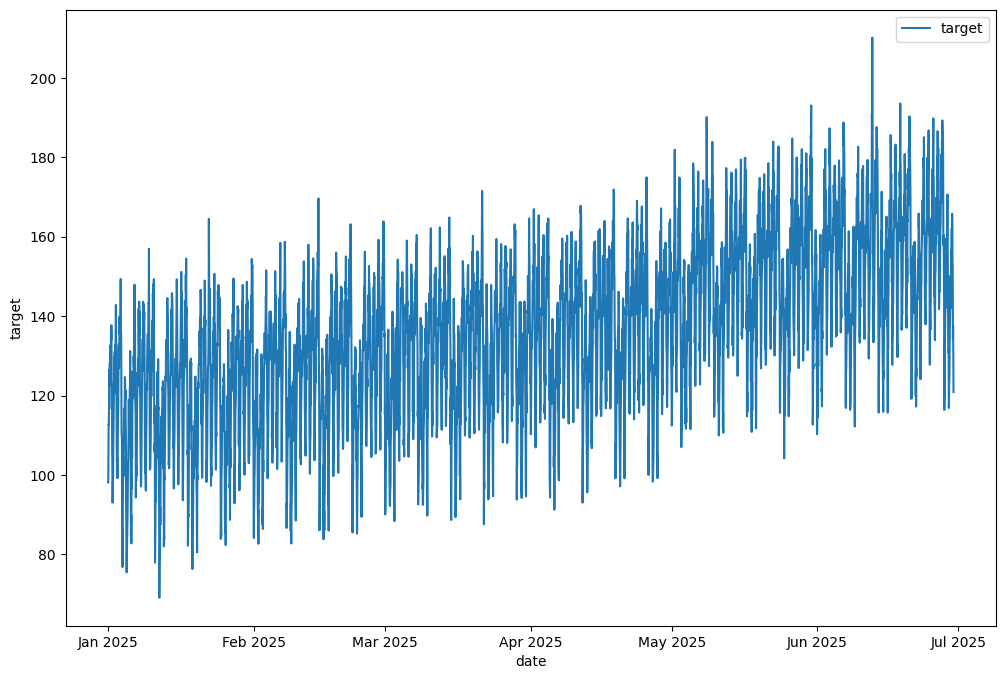

In [20]:
plt.figure(figsize=(12, 8))
plt.plot(df['date'], df['target'], label='target')

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

plt.xlabel('date')
plt.ylabel('target')
plt.grid(False)
plt.legend()
plt.show()

## Комментарии датасета

Можем заметить тренд на увеличение примерно с 110 до 160 среднего, выбросы присутствуют, но их кол-во незначительно

In [22]:
def temporal_split(df: pd.DataFrame, train_size: float, val_size: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.sort_values('date').reset_index(drop=True)

    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * val_size) + train_end

    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df, train_size=0.7, val_size=0.15)

print('train shape:', train_df.shape)
print('val shape:', val_df.shape)
print('test shape:', test_df.shape)

train shape: (3024, 2)
val shape: (648, 2)
test shape: (648, 2)


## Why random split is not suitable for this task

Random split shuffle our dataset, but temporal split does not do this

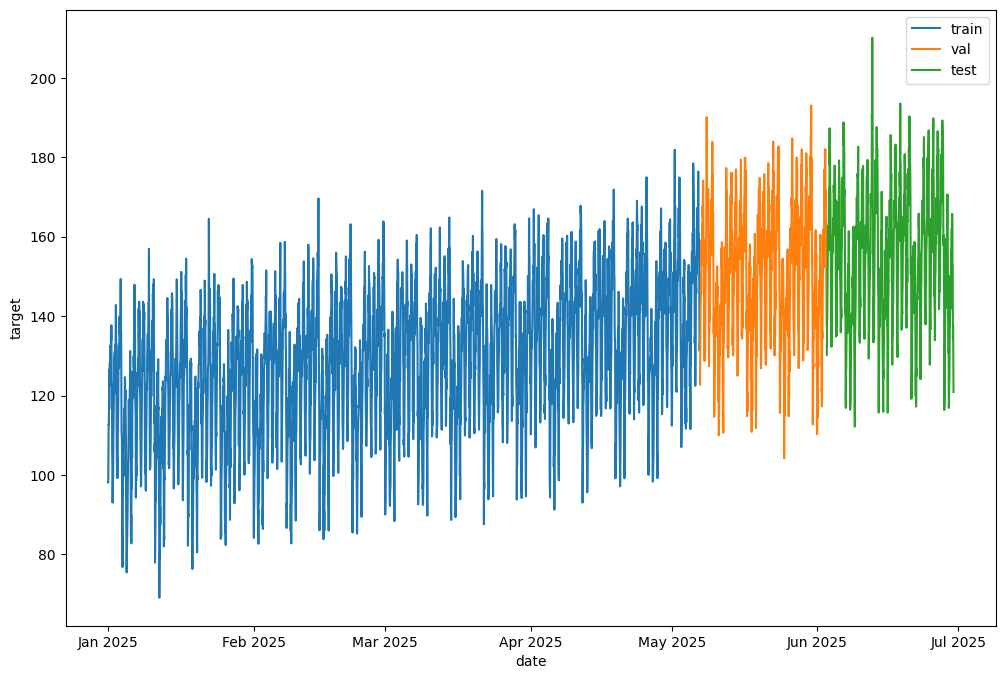

In [23]:
plt.figure(figsize=(12, 8))

plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'], val_df['target'], label='val')
plt.plot(test_df['date'], test_df['target'], label='test')

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

plt.legend()
plt.xlabel('date')
plt.ylabel('target')
plt.grid(False)
plt.show()

In [32]:
def make_new_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    lags = [1, 7, 14]
    for lag in lags:
        df[f'lag_{lag}'] = df['target'].shift(lag)

    df['rolling_mean_7'] = df['target'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(7).std()

    date_series: pd.Series = pd.to_datetime(df['date'])
    df['weekday'] = date_series.dt.dayofweek

    df = df.dropna()

    return df

df = make_new_features(df)
df.head(5)

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,weekday
56,2025-01-03 08:00:00,126.91,132.92,99.25,130.48,118.628571,12.257729,4
57,2025-01-03 09:00:00,130.41,126.91,110.05,122.34,122.580000,8.993220,4
58,2025-01-03 10:00:00,134.79,130.41,113.09,108.30,125.488571,7.420214,4
59,2025-01-03 11:00:00,139.94,134.79,117.58,104.26,128.588571,5.713719,4
60,2025-01-03 12:00:00,135.41,139.94,126.38,99.27,131.782857,4.692575,4


In [35]:
train_X = train_df.drop(columns=['target'])
train_Y = train_df['target']

val_X = val_df.drop(columns=['target'])
val_Y = val_df['target']

test_X = test_df.drop(columns=['target'])
test_Y = test_df['target']

In [37]:
scaller = StandardScaler()
train_scaller = scaller.fit_transform(train_X)
val_scaller = scaller.transform(val_X)
test_scaller = scaller.transform(test_X)

In [39]:
def make_windows(
        X: pd.DataFrame | np.ndarray,
        Y: pd.Series | np.ndarray,
        window_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    if isinstance(Y, pd.Series):
        Y = Y.to_numpy()

    X_windows = []
    Y_windows = []

    for i in range(len(X) - window_size):
        X_windows.append(X[i:i + window_size])
        Y_windows.append(Y[i + window_size])

    return np.array(X_windows), np.array(Y_windows)


class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, X: pd.DataFrame, Y: pd.DataFrame) -> None:
        self.X = torch.tensor(X, dtype=torch.float)
        self.Y = torch.tensor(Y, dtype=torch.float)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, item):
        return self.X[item], self.Y[item]


def train_one_epoch(
        model: nn.Module,
        optimizer: optim.Optimizer,
        criterion: nn.Module,
        loader: torch.utils.data.DataLoader,
        device: torch.device,
) -> tuple[float, float]:
    model.train()

    total_loss, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(x).squeeze(-1)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

    return total_loss / total, total


@torch.no_grad()
def evaluate(
        model: nn.Module,
        criterion: nn.Module,
        loader: torch.utils.data.DataLoader,
        device: torch.device,
) -> tuple[float, float]:
    model.eval()

    loss, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        preds = model(x).squeeze(-1)
        loss += criterion(preds, y).item() * y.size(0)
        total += y.size(0)

    return loss / total, total


def fit(
        model: nn.Module,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
        train_loader: torch.utils.data.DataLoader,
        val_loader: torch.utils.data.DataLoader,
        epochs: int,
        device: torch.device,
        verbose: bool = False,
):
    model.train()
    model.to(device)

    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(epochs):

        train_loss, train_total = train_one_epoch(
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            loader=train_loader,
            device=device,
        )

        val_loss, val_total = evaluate(
            model=model,
            criterion=criterion,
            loader=val_loader,
            device=device,
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f'epoch: {epoch} || train_loss: {train_loss} || val_loss: {val_loss}')


    return history

def metrics(y_pred, y_true):
    MAE = np.abs(y_pred - y_true).mean()
    RMSE = np.sqrt(np.mean((y_pred - y_true) ** 2))
    MAPE = np.mean((y_true - y_pred) / y_true) * 100

    return {'mae': MAE, 'rmse': RMSE, 'mape': MAPE}